In [7]:
%pip uninstall -y tensorflow tensorflow_cpu tensorflow-intel keras
%pip install -q --upgrade --force-reinstall "tensorflow==2.20.0" scikit-learn seaborn matplotlib pandas numpy sastrawi nltk wordcloud

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: keras 3.14.0
Uninstalling keras-3.14.0:
  Successfully uninstalled keras-3.14.0
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.


In [8]:
import os
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import datetime as dt
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt_tab')  # Kompatibel untuk NLTK versi baru yang membutuhkan resource punkt_tab.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
DATA_PATH = Path("content/reviews_duolingo.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "File /content/reviews_duolingo.csv belum ditemukan. Jalankan notebook scrapping.ipynb terlebih dahulu."
    )

df = pd.read_csv(DATA_PATH)
print("Shape data awal:", df.shape)
df.head()

Shape data awal: (19819, 9)


,review_id,app_id,app_name,user_name,score,content,thumbs_up,at,app_version
0,7852f726-11f1-4de3-8bab-1add6f09d7f7,com.duolingo,DUOLINGO,Farhan Abdillah,5,gak ada update aku versi old,0,2026-04-26 13:24:18,5.121.14
1,4ba770cc-55dc-41cc-bd78-04524bf94c98,com.duolingo,DUOLINGO,Devi Melani,3,"Why is this app so slow? Previously, I was studying smoothly without any problems, but now, just opening a single le...",0,2026-04-26 13:11:49,NaN
2,3652eaa4-5f07-4c5f-b79a-b6bcb9a1bbb6,com.duolingo,DUOLINGO,Nun_azzahh,5,"Duolingo ngebantu banget , asalnya aku main duolingo main belajar di duolingo cuman buat b inggris trs aku ikut esku...",0,2026-04-26 12:49:42,6.71.2
3,435b2c23-4849-41e6-9f65-54117fc4950c,com.duolingo,DUOLINGO,Sukarti 12,5,bagus sih ini saya jadi bisa belajar bahasa Inggris tapi ada yang aneh pas aku pake tulisan premium malah salah koca...,0,2026-04-26 11:44:12,6.76.3
4,be0eb54e-bd00-4e93-b420-4ed34ca9682c,com.duolingo,DUOLINGO,Alleya zevania Kiara,5,bagus buat lagi yang belajar bahasa asing,0,2026-04-26 11:40:01,5.141.11


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19819 entries, 0 to 19818
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    19819 non-null  str  
 1   app_id       19819 non-null  str  
 2   app_name     19819 non-null  str  
 3   user_name    19819 non-null  str  
 4   score        19819 non-null  int64
 5   content      19819 non-null  str  
 6   thumbs_up    19819 non-null  int64
 7   at           19819 non-null  str  
 8   app_version  18165 non-null  str  
dtypes: int64(2), str(7)
memory usage: 1.4 MB


In [23]:
clean_df = df.dropna()
clean_df = clean_df.drop_duplicates()

clean_df.info()

<class 'pandas.DataFrame'>
Index: 18165 entries, 0 to 19818
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    18165 non-null  str  
 1   app_id       18165 non-null  str  
 2   app_name     18165 non-null  str  
 3   user_name    18165 non-null  str  
 4   score        18165 non-null  int64
 5   content      18165 non-null  str  
 6   thumbs_up    18165 non-null  int64
 7   at           18165 non-null  str  
 8   app_version  18165 non-null  str  
dtypes: int64(2), str(7)
memory usage: 1.4 MB


In [58]:
display(clean_df["score"].value_counts().sort_index())

score
1      408
2      153
3      421
4     1833
5    15350
Name: count, dtype: int64

In [59]:
# Target lebih besar namun tetap wajar: total sentimen dibuat seimbang (900 per sentimen)
target_counts = {
    1: 600,  # negative
    2: 300,  # negative
    3: 900,  # neutral
    4: 450,  # positive
    5: 450,  # positive
}

balanced_parts = []
for score, target_n in target_counts.items():
    subset = clean_df[clean_df['score'] == score]
    if subset.empty:
        raise ValueError(f"Score {score} tidak ditemukan pada clean_df")

    # Oversampling dipakai hanya jika data asli kurang dari target
    use_replace = len(subset) < target_n
    sampled_subset = subset.sample(n=target_n, replace=use_replace, random_state=SEED)
    balanced_parts.append(sampled_subset)

balanced_df = (
    pd.concat(balanced_parts, axis=0)
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)

print("Distribusi score pada balanced_df:")
display(balanced_df['score'].value_counts().sort_index())

sentiment_from_score = balanced_df['score'].map(
    lambda s: 'negative' if s <= 2 else ('neutral' if s == 3 else 'positive')
)
print("Distribusi sentimen (berdasarkan score):")
display(sentiment_from_score.value_counts())

Distribusi score pada balanced_df:


score
1    600
2    300
3    900
4    450
5    450
Name: count, dtype: int64

Distribusi sentimen (berdasarkan score):


score
neutral     900
negative    900
positive    900
Name: count, dtype: int64

In [62]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text, preserve_line=True)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [63]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

def label_from_score(score: int) -> str:
    if score <= 2:
        return "negative"
    if score == 3:
        return "neutral"
    return "positive"

In [64]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
balanced_df['text_clean'] = balanced_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
balanced_df['text_casefoldingText'] = balanced_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
balanced_df['text_slangwords'] = balanced_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
balanced_df['text_tokenizingText'] = balanced_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
balanced_df['text_stopword'] = balanced_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
balanced_df['text_akhir'] = balanced_df['text_stopword'].apply(toSentence)

balanced_df["sentiment"] = balanced_df["score"].astype(int).apply(label_from_score)

label_to_id = {"negative": 0, "neutral": 1, "positive": 2}
id_to_label = {v: k for k, v in label_to_id.items()}
balanced_df["label_id"] = balanced_df["sentiment"].map(label_to_id)

print("Shape setelah preprocessing:", balanced_df.shape)
balanced_df[["score", "sentiment", "text_clean"]].head()

Shape setelah preprocessing: (2700, 17)


,score,sentiment,text_clean
0,3,neutral,eee lebih baik dulu sistem nya ga make energykalo sekarang pake energy jadi boros banget jadi males buka duo linggo ...
1,3,neutral,aplikasinya bagus banget saya suka Tetapi saya masi sedikit kecewa karna setiap saya bicara menurut teks tetap tidak...
2,3,neutral,baguss tapi sering nge lagg
3,2,negative,bagus sih tapi gak ada bahasa Serbia
4,3,neutral,bagus tapi ngulang terus pembelalajrannya


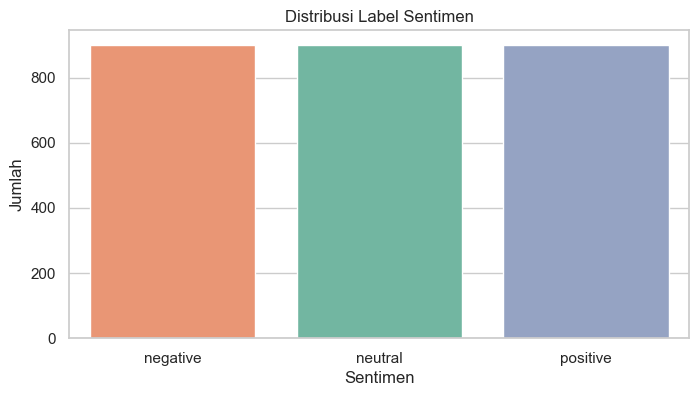

sentiment
neutral     900
negative    900
positive    900
Name: count, dtype: int64

In [65]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=balanced_df,
    x="sentiment",
    order=["negative", "neutral", "positive"],
    palette="Set2",
    hue="sentiment",
    legend=False
  )
ax.set_title("Distribusi Label Sentimen")
ax.set_xlabel("Sentimen")
ax.set_ylabel("Jumlah")
plt.show()

balanced_df["sentiment"].value_counts()

In [66]:
# Pakai teks hasil preprocessing lanjutan agar sinyal sentimen lebih bersih
X = balanced_df["text_akhir"].astype(str).to_numpy(dtype=str)
y = balanced_df["label_id"].astype("int32").to_numpy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Jumlah data:")
print("Train:", len(X_train))
print("Val  :", len(X_val))
print("Test :", len(X_test))
print("Dtype X_train:", X_train.dtype, "| Dtype y_train:", y_train.dtype)

Jumlah data:
Train: 1890
Val  : 405
Test : 405
Dtype X_train: <U364 | Dtype y_train: int32


In [67]:
MAX_TOKENS = 30000
SEQ_LENGTH = 120
BATCH_SIZE = 64
EPOCHS = 12


def compile_and_train(model, x_train, y_train, x_val, y_val, model_name: str):
    # Keras pada environment ini lebih stabil jika input teks dipaksa menjadi tensor tf.string
    x_train = tf.constant(np.asarray(x_train), dtype=tf.string)
    y_train = tf.constant(np.asarray(y_train), dtype=tf.int32)
    x_val = tf.constant(np.asarray(x_val), dtype=tf.string)
    y_val = tf.constant(np.asarray(y_val), dtype=tf.int32)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=2, mode="max", restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5
        ),
    ]

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks,
    )

    return history


def evaluate_model(model, x_test, y_test, model_name: str):
    x_test = tf.constant(np.asarray(x_test), dtype=tf.string)
    y_test = np.asarray(y_test, dtype=np.int32)

    pred_probs = model.predict(x_test, verbose=0)
    y_pred = pred_probs.argmax(axis=1)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n[{model_name}] Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["negative", "neutral", "positive"]))
    return acc, y_pred

## Eksperimen 1: TF-IDF (TextVectorization) + Dense Neural Network

In [68]:
vectorizer_tfidf = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    ngrams=2,
    output_mode="tf_idf",
)
vectorizer_tfidf.adapt(X_train)

inp = keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer_tfidf(inp)
x = layers.Dense(
    512,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4),
)(x)
x = layers.LayerNormalization()(x)
x = layers.Dropout(0.45)(x)
x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4),
)(x)
x = layers.Dropout(0.35)(x)
out = layers.Dense(3, activation="softmax")(x)

model_1 = keras.Model(inp, out, name="tfidf_bigram_dense")
model_1.summary()

Model: "tfidf_bigram_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_6            │ (None, 1, 10567)       │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1, 512)         │     5,410,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 1, 512)         │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1, 256)         │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1, 3)           │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,543,939 (21.15 MB)

 Trainable params: 5,543,939 (21.15 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
history_1 = compile_and_train(model_1, X_train, y_train, X_val, y_val, "TFIDF + Dense")
acc_1, pred_1 = evaluate_model(model_1, X_test, y_test, "TFIDF + Dense")

Epoch 1/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.5286 - loss: 1.3322 - val_accuracy: 0.7210 - val_loss: 0.7842 - learning_rate: 0.0010
Epoch 2/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.8651 - loss: 0.4312 - val_accuracy: 0.7531 - val_loss: 0.7096 - learning_rate: 0.0010
Epoch 3/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.9354 - loss: 0.2497 - val_accuracy: 0.7531 - val_loss: 0.7686 - learning_rate: 0.0010
Epoch 4/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.9450 - loss: 0.2069 - val_accuracy: 0.7580 - val_loss: 0.7829 - learning_rate: 5.0000e-04
Epoch 5/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9497 - loss: 0.2060 - val_accuracy: 0.7481 - val_loss: 0.7802 - learning_rate: 2.5000e-04
Epoch 6/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.9556 - loss: 0.1873 - val_accuracy: 0.7506 - val_loss: 0.7828 - learning_rate: 1.2500e-04

[TFIDF + Dense] Test Accuracy: 0.7901
              precision    recall  f1

## Eksperimen 2: Sequence Vectorization + Embedding + BiLSTM

In [70]:
vectorizer_seq = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=SEQ_LENGTH,
)
vectorizer_seq.adapt(X_train)

inp2 = keras.Input(shape=(1,), dtype=tf.string)
x2 = vectorizer_seq(inp2)
x2 = layers.Embedding(input_dim=MAX_TOKENS, output_dim=128, mask_zero=True)(x2)
x2 = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x2)
x2 = layers.Bidirectional(layers.LSTM(32))(x2)
x2 = layers.Dropout(0.35)(x2)
x2 = layers.Dense(64, activation="relu")(x2)
out2 = layers.Dense(3, activation="softmax")(x2)

model_2 = keras.Model(inp2, out2, name="seq_bilstm")
model_2.summary()

Model: "seq_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 120)       │          0 │ input_layer_7[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 120, 128)  │  3,840,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 120)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 120, 128)  │     98,816 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 64)        │     41,216 │ bidirectional_2[… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ bidirectional_3[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │      4,160 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 3)         │        195 │ dense_20[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,984,387 (15.20 MB)

 Trainable params: 3,984,387 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
history_2 = compile_and_train(model_2, X_train, y_train, X_val, y_val, "Seq + BiLSTM")
acc_2, pred_2 = evaluate_model(model_2, X_test, y_test, "Seq + BiLSTM")

print(f"Akurasi Model 1 (TFIDF + Dense): {acc_1:.4f}")
print(f"Akurasi Model 2 (Seq + BiLSTM): {acc_2:.4f}")

Epoch 1/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 270ms/step - accuracy: 0.4048 - loss: 1.0743 - val_accuracy: 0.5012 - val_loss: 1.0058 - learning_rate: 0.0010
Epoch 2/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 261ms/step - accuracy: 0.6714 - loss: 0.8207 - val_accuracy: 0.6198 - val_loss: 0.8489 - learning_rate: 0.0010
Epoch 3/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 265ms/step - accuracy: 0.7931 - loss: 0.5406 - val_accuracy: 0.6642 - val_loss: 0.8427 - learning_rate: 0.0010
Epoch 4/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 270ms/step - accuracy: 0.8646 - loss: 0.3799 - val_accuracy: 0.6914 - val_loss: 0.9547 - learning_rate: 0.0010
Epoch 5/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step - accuracy: 0.8915 - loss: 0.2950 - val_accuracy: 0.7086 - val_loss: 0.9783 - learning_rate: 5.0000e-04
Epoch 6/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 269ms/step - accuracy: 0.9042 - loss: 0.2569 - val_accuracy: 0.7111 - val_loss: 1.0124 - learning_rate: 2.5000e-04
Epoch 7/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 284ms/step - accuracy: 0.9111 - loss: 

In [72]:
print("acc_1 =", round(float(acc_1), 4))
print("acc_2 =", round(float(acc_2), 4))
print("improvement =", round(float(acc_2 - acc_1), 4))

acc_1 = 0.7901
acc_2 = 0.7383
improvement = -0.0519
